# Precios y retornos

En esta sesión examinaremos el comportamiento de algunos precios de activos y sus retornos

### Cargamos las librerias y los datos

Para la programación en R, seguiremos mayormente el flujo de trabajo y la sintaxsis de [Forecasting Principles and Practice](https://otexts.com/fpp3/)

In [1]:
library(readxl)
library(dplyr)
library(ggpubr)
library(tsibble)
library(feasts)
library(tidyquant)
library(ggplot2)
library(ggtime)
library(moments)


Warning message:
package ‘readxl’ was built under R version 4.5.3 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.5.3 


Loading required package: ggplot2


Warning message:
package ‘ggpubr’ was built under R version 4.5.3 


...

Loading required package: fabletools


Warning messages:
1: package ‘feasts’ was built under R version 4.5.3 
2: package ‘fabletools’ was built under R version 4.5.3 


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 
── Attaching core tidyquant packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyquant 1.0.12 ──
✔ PerformanceAnalytics 2.1.0      ✔ TTR                  0.24.4
✔ quantmod             0.4.29     ✔ xts                  0.14.2
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ dplyr::filter()                masks stats::filter()
✖ xts::first()                   masks dplyr::first()
✖ zoo::index()                   masks tsibble::index()
✖ dplyr::lag()                   masks stats::lag()
✖ xts::last()                    masks dplyr::last()
✖ Pe

Warning messages:
1: package ‘tidyquant’ was built under R version 4.5.3 
2: package ‘xts’ was built under R version 4.5.3 
3: package ‘quantmod’ was built under R version 4.5.3 
4: package ‘TTR’ was built under R version 4.5.3 
5: package ‘PerformanceAnalytics’ was built under R version 4.5.3 
Warning message:
package ‘ggtime’ was built under R version 4.5.3 



Attaching package: ‘moments’

The following objects are masked from ‘package:PerformanceAnalytics’:

    kurtosis, skewness



Para ilustrar usaremos dos activos, Bitcoin, y la acción de Ecopetrol en NYSE (ADS). Cargamos los datos de cierre diario usando Yahoo Finance

In [8]:
btc_close<-tq_get("BTC-USD", get = "stock.prices",from="2022-01-01")|>select(date, close)
btc_close<-as_tsibble(btc_close,index=date)

ec_close<-tq_get("EC", get = "stock.prices",from="2022-01-01")|>select(date, close)
ec_close<-as_tsibble(ec_close,index=date)

Para cada uno de los activos hacemos la transformación logarítmica y calculamos el retorno diario $r_t=ln(P_t/P_{t-1})$

In [9]:
btc_close<-btc_close|>mutate(lclose=log(close),dlclose=lclose-lag(lclose))
ec_close<-ec_close|>mutate(lclose=log(close),dlclose=lclose-lag(lclose))

Warning message:
Removed 3 rows containing missing values or values outside the scale range (`geom_line()`). 


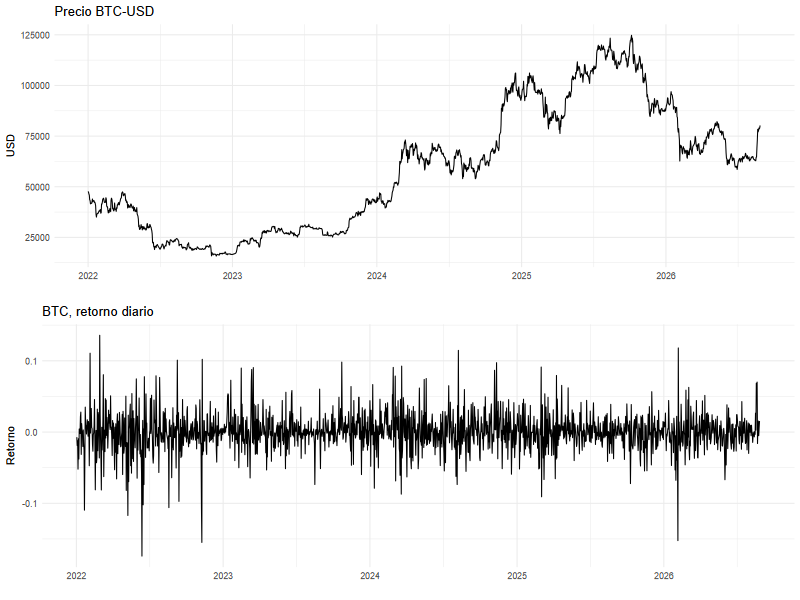

In [10]:
btc.plot<-ggplot(btc_close,aes(x=date,y=close))+geom_line()+
  labs(title="Precio BTC-USD",x="", y="USD")+theme_minimal()
dbtc.plot<-ggplot(btc_close,aes(x=date,y=dlclose))+geom_line()+
  labs(title="BTC, retorno diario",x="", y="Retorno")+theme_minimal()

ggarrange(btc.plot,dbtc.plot,ncol=1)

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 


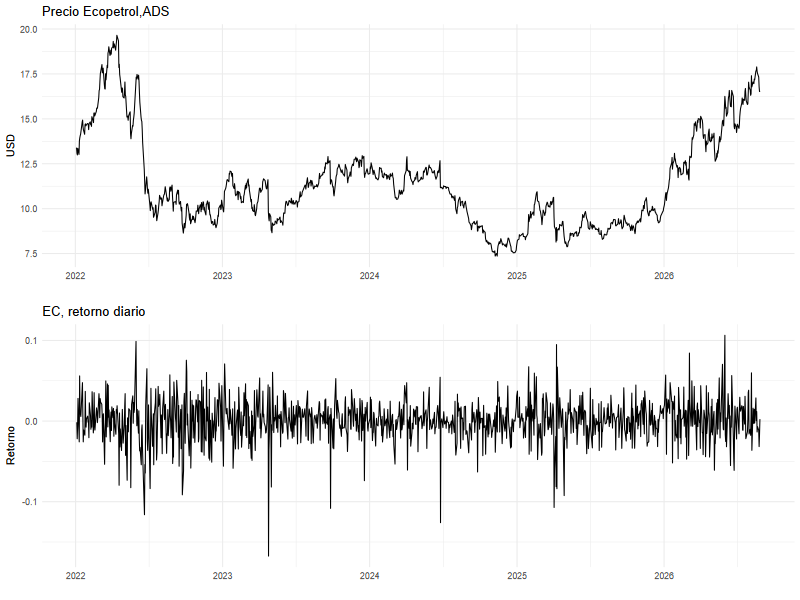

In [11]:
ec.plot<-ggplot(ec_close,aes(x=date,y=close))+geom_line()+
  labs(title="Precio Ecopetrol,ADS",x="", y="USD")+theme_minimal()
dec.plot<-ggplot(ec_close,aes(x=date,y=dlclose))+geom_line()+
  labs(title="EC, retorno diario",x="", y="Retorno")+theme_minimal()

ggarrange(ec.plot,dec.plot,ncol=1)

Ahora examinamos La función de densidad para los retornos y calculamos sus momentos muestrales

Warning messages:
1: Removed 3 rows containing non-finite outside the scale range (`stat_density()`). 
2: Removed 2 rows containing non-finite outside the scale range (`stat_density()`). 


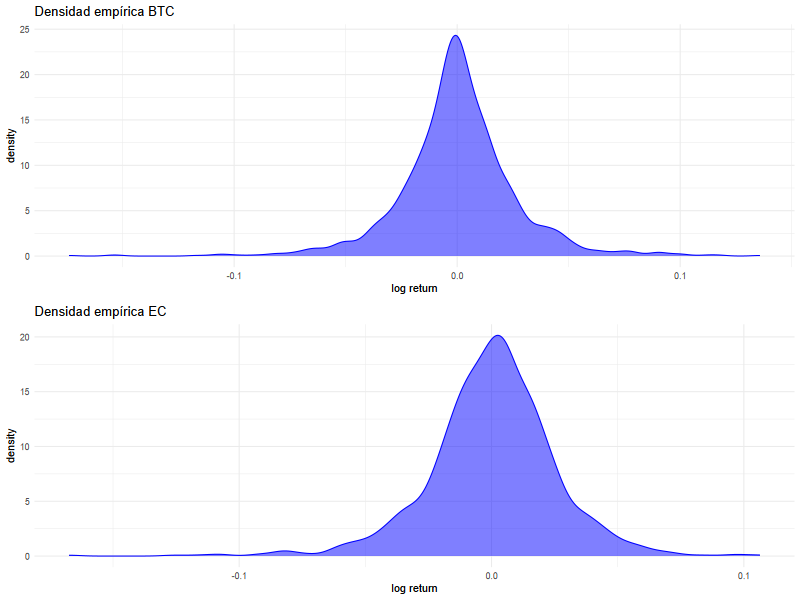

In [12]:
dbtc.density<-ggplot(btc_close,aes(x=dlclose))+geom_density(color="blue",fill="blue",alpha=0.5)+
  theme_minimal()+labs(title="Densidad empírica BTC",x="log return")
dec.density<-ggplot(ec_close,aes(x=dlclose))+geom_density(color="blue",fill="blue",alpha=0.5)+
  theme_minimal()+labs(title="Densidad empírica EC",x="log return")

ggarrange(dbtc.density,dec.density,ncol=1)

In [13]:
btc_moments<-btc_close|>as_tibble()|>
  summarise(mdlclose=mean(dlclose,na.rm=TRUE),
                                  sddlclose=sd(dlclose,na.rm=TRUE),
                                skewdlclose=skewness(dlclose,na.rm=TRUE),
                              kdlclose=kurtosis(dlclose,na.rm=TRUE)-3)
print(btc_moments)

# A tibble: 1 × 4
  mdlclose sddlclose skewdlclose kdlclose
     <dbl>     <dbl>       <dbl>    <dbl>
1 0.000306    0.0267      -0.175     4.83


In [14]:
ec_moments<-ec_close|>as_tibble()|>
  summarise(mdlclose=mean(dlclose,na.rm=TRUE),
                                  sddlclose=sd(dlclose,na.rm=TRUE),
                                skewdlclose=skewness(dlclose,na.rm=TRUE),
                              kdlclose=kurtosis(dlclose,na.rm=TRUE)-3)
print(ec_moments)

# A tibble: 1 × 4
  mdlclose sddlclose skewdlclose kdlclose
     <dbl>     <dbl>       <dbl>    <dbl>
1 0.000182    0.0254      -0.587     3.78


Como se observa en las grtáficas, y se verifica con la estadística descriptiva, los retornos tienen exceso de curtosis, el retorno promedio es cercano a cero, y la asimetría no es mayor problema. 

## Podemos calcular los retornos acumulados y el CAGR

Calculamos los retornos acumulados para todo el periodo

In [15]:
btc_cum<-sum(btc_close$dlclose,na.rm=TRUE)
print(btc_cum)

[1] 0.5205858


Que no es otra cosa que el retorno promedio por el número de días de negociación

In [16]:
mean(btc_close$dlclose,na.rm=TRUE)*(nrow(btc_close)-1)

[1] 0.5211986

El retorno anualizado lo computamos como el acumulado sobre el número de años

In [17]:
btc_anual<-btc_cum/((nrow(btc_close)-1)/365)
print(btc_anual)

[1] 0.1117071


Que al expresarlo como el CAGR es

In [18]:
btc_cagr<-exp(btc_anual)-1
print(btc_cagr)

[1] 0.1181853


### Actividad

- Elija dos series financieras de su interés, consiga los datos en frecuencia diaria, y realice el análisis anterior
- Para todas las series, agregue los datos a frecuencia mensual. Es decir, debe tener el retorno mensual para cada serie, y realice nuevamente los gráficos de densidad y las estadísticas descriptivas. ¿La agregación cambia las propiedades de las series?